<a href="https://colab.research.google.com/github/caroalvarado/MachineLearning/blob/main/Proyecto_U3_5_Modelos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**"Machine Learning"**
#**Proyecto Unidad III**

##Equipo:
##*Carolina Alvarado Hernández.*

##*Jorge Alejandro Fernández De Los Santos.*

##*Facilitador: José Gabriel Rodríguez Rivas.*


#**Introducción**

#**Librerías iniciales y datasets**

In [ ]:
#Cargar librerías iniciales
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import gdown

#Cargar Datasets:
file_ids = [
    "1mAK15DFvuGkFXRMAPLYcQ0wq56fE5nXW",
    "1slIscrXmGvSX31-3iwKUfqks7eGFqyAE",
    "1hCSKKiVDj4Wci2JqHmCQY5pnDn8DN2ov"
]

for file_id in file_ids:
    url = f'https://drive.google.com/uc?id={file_id}'
    gdown.download(url, quiet=False)

#Datasets legibles
df_train = pd.read_csv('Tinanitc-data-train.csv')
df_test_features = pd.read_csv('Tinanitc-data-test.csv')
df_test_labels = pd.read_csv('Tinanitc-data-gender.csv')

Downloading...
From: https://drive.google.com/uc?id=1mAK15DFvuGkFXRMAPLYcQ0wq56fE5nXW
To: /content/Tinanitc-data-gender.csv
100%|██████████| 3.26k/3.26k [00:00<00:00, 9.64MB/s]
Downloading...
From: https://drive.google.com/uc?id=1slIscrXmGvSX31-3iwKUfqks7eGFqyAE
To: /content/Tinanitc-data-test.csv
100%|██████████| 28.6k/28.6k [00:00<00:00, 44.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1hCSKKiVDj4Wci2JqHmCQY5pnDn8DN2ov
To: /content/Tinanitc-data-train.csv
100%|██████████| 61.2k/61.2k [00:00<00:00, 33.8MB/s]


##Una vez que son cargados los datasets, al tener datos en conjunto separados se deben de unir para poder ser analizados y limpiados.

In [ ]:
#Se unen las características de cada dataset con sus etiqueta, en este caso se usará la de "supervivencia"
df_test = pd.merge(df_test_features, df_test_labels, on='PassengerId')

#Juntar train y test en un solo DataFrame general para luego dividirlo al 70/30 en entrenamiento y pruebas
df = pd.concat([df_train, df_test], ignore_index=True)

#**1. Análisis Exploratorio de Datos**

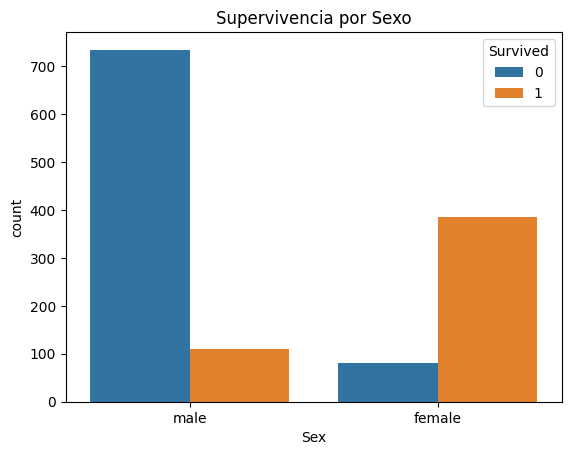

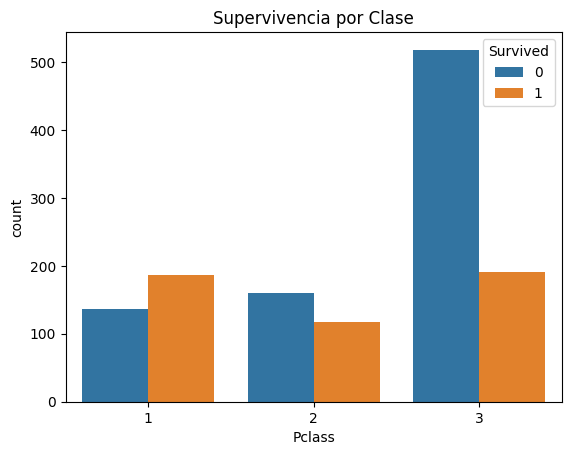

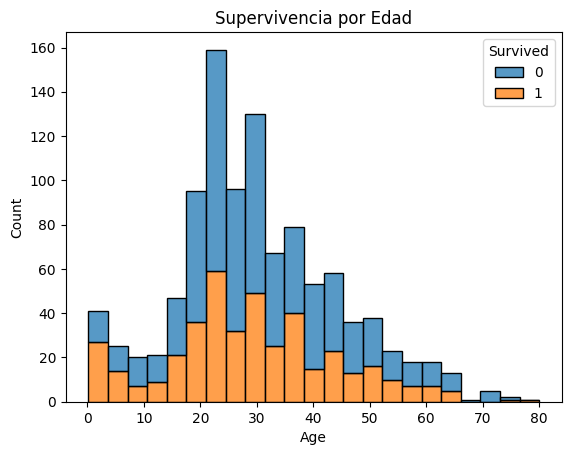

In [ ]:
#Comprensión de los datos
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Supervivencia por Sexo')
plt.show()

sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title('Supervivencia por Clase')
plt.show()

sns.histplot(data=df, x='Age', hue='Survived', multiple='stack')
plt.title('Supervivencia por Edad')
plt.show()

## Como se pueden observar en las gráficas, las cantidades de bajas (Los valores 0) es mayor a la cantidad de los supervivientes (Valor 1).


Una vez que se conocen los sobrevivientes de forma categórica, es momento de eliminar los datos que pueden interferir en una correcta ejecución de los distintos modelos. Lo que se conoce de mejor forma como la preparación de los datos para ser utilizados.

In [ ]:
#Limpieza de valores nulos
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop('Cabin', axis=1)
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

##Después de haber limpiado los datos, se deben seleccionar las variables que alimentaran a los modelos de forma significativa.

In [ ]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'
X = df[features].copy()
y = df[target]

# Ensure 'Age' has no NaN values in X before splitting
X['Age'] = X['Age'].fillna(X['Age'].mean())

##Los algoritmos al comprender únicamente números, se deben traducir esas categorías al lenguaje que entiende la computadora, para que pueda procesar los datos de forma adecuada sin alterar el significado de la información.

In [ ]:
#Usa para la variable de género, asignando un 0 para masculino y un 1 para femenino.
if 'Sex' in X.columns:
    X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})

if 'Embarked' in X.columns:
    X = pd.get_dummies(X, columns=['Embarked'], drop_first=True)
    # Se convierten las columnas booleanas creadas por get_dummies a tipo entero (int)
    # Estas columnas solo existirán si 'Embarked' estaba presente y fue procesada con get_dummies
    if 'Embarked_Q' in X.columns and 'Embarked_S' in X.columns:
        X[['Embarked_Q', 'Embarked_S']] = X[['Embarked_Q', 'Embarked_S']].astype(int)

##La razón de la limpíeza está en que:


* **En KNN y SVM:** Miden la distancia geométrica entre los pasajeros. Para medir distancias, necesitan coordenadas estrictamente numéricas.

* **En Regresión Logística:** Multiplica el valor de cada variable por un coeficiente matemático para calcular una probabilidad. No se puede multiplicar una palabra por un número.

* **Dentro de Árboles de Decisión y Random Forest:** Buscan el mejor punto de corte matemático para separar a los que sobrevivieron de los que no, se requieren de valores numéricos para evaluar esas reglas.


In [ ]:
#División del dataset (70% entrenamiento, 30% pruebas)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [ ]:
#Escalamiento de variables numéricas
scaler = StandardScaler()
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

##Se escalan los datos de entrenamiento generales porque se van a usar esos mismos datos para alimentar a los 5 modelos, además, es más fácil pasarles los datos ya escalados a todos. Cabe resaltar que a los árboles no les afecta negativamente que los datos estén escalados, porque simplemente no lo aprovechan.

#**2. Evaluación de los 5 modelos**

In [ ]:
#Importación de las métricas necesarias
from sklearn.metrics import classification_report, confusion_matrix

##**1: K-Nearest Neighbors (KNN)**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

print("Evaluación: KNN")
# 1. Instanciar y Entrenar
modelo_knn = KNeighborsClassifier()
modelo_knn.fit(X_train, y_train)

# 2. Predecir
y_pred_knn = modelo_knn.predict(X_test)

# 3. Reporte y Matriz
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_knn))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_knn))

Evaluando: KNN
Matriz de Confusión:
[[218  27]
 [ 45 103]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       245
           1       0.79      0.70      0.74       148

    accuracy                           0.82       393
   macro avg       0.81      0.79      0.80       393
weighted avg       0.82      0.82      0.81       393



Estos resultados muestran que el modelo predijo correctamente que 218 personas fallecieron y que 103 personas sí sobrevivieron.
También que hubo 45 personas que en la vida real sí sobrevivieron, pero el modelo predijo de forma errónea que habían fallecido. A su vez, los resultados del modelo dice expuso que 27 personas habían sobrevivido, cuando realmente habían fallecido.

**Exactitud (Accuracy):** El modelo tiene una precisión general del 82%.

**Recall de la Clase 0 (0.89):** De todas las personas que realmente fallecieron, el modelo logró encontrar y clasificar correctamente al 89% de ellas.

**Recall de la Clase 1 (0.70):** De todas las personas que realmente sobrevivieron, el modelo solo pudo detectar al 70%. A este modelo le cuesta un poco más de trabajo identificar correctamente a los sobrevivientes que a los fallecidos.

##**2: Regresión Logística**

In [ ]:
from sklearn.linear_model import LogisticRegression

print("Evaluación: Regresión Logística")
# 1. Instanciar y Entrenar
modelo_rl = LogisticRegression(random_state=42)
modelo_rl.fit(X_train, y_train)

# 2. Predecir
y_pred_rl = modelo_rl.predict(X_test)

# 3. Reporte y Matriz
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_rl))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rl))

Evaluación: Regresión Logística
Matriz de Confusión:
[[227  18]
 [ 38 110]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.86      0.93      0.89       245
           1       0.86      0.74      0.80       148

    accuracy                           0.86       393
   macro avg       0.86      0.83      0.84       393
weighted avg       0.86      0.86      0.86       393



Con regresión logística el modelo predijo correctamente que 227 personas fallecieron y que 110 personas sí sobrevivieron. También que hubo 38 personas que en la vida real sí sobrevivieron, pero el modelo predijo de forma errónea que habían fallecido. A su vez, los resultados del modelo dice expuso que 18 personas habían sobrevivido, cuando realmente habían fallecido.

**Exactitud (Accuracy):** El modelo tiene una precisión general del 86%.

**Recall de la Clase 0 (0.93):** De todas las personas que realmente fallecieron, el modelo logró encontrar y clasificar correctamente al 93% de ellas.

**Recall de la Clase 1 (0.74):** De todas las personas que realmente sobrevivieron, el modelo solo pudo detectar al 74%. A este modelo le cuesta un poco más de trabajo identificar correctamente a los sobrevivientes que a los fallecidos, aunque tiene un desempeño notablemente superior al anterior.

##**3: Árbol de Decisión**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

print("Evaluación: Árbol de Decisión")
# 1. Instanciar y Entrenar
modelo_arbol = DecisionTreeClassifier(random_state=42)
modelo_arbol.fit(X_train, y_train)

# 2. Predecir
y_pred_arbol = modelo_arbol.predict(X_test)

# 3. Reporte y Matriz
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_arbol))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_arbol))

Evaluación: Árbol de Decisión
Matriz de Confusión:
[[214  31]
 [ 38 110]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       245
           1       0.78      0.74      0.76       148

    accuracy                           0.82       393
   macro avg       0.81      0.81      0.81       393
weighted avg       0.82      0.82      0.82       393



El modelo de árbol de decisión predijo correctamente que 214 personas fallecieron y que 110 personas sí sobrevivieron. También que hubo 38 personas que en la vida real sí sobrevivieron, pero el modelo predijo de forma errónea que habían fallecido. A su vez, los resultados del modelo dice expuso que 31 personas habían sobrevivido, cuando realmente habían fallecido.

**Exactitud (Accuracy):** El modelo tiene una precisión general del 82%.

**Recall de la Clase 0 (0.87):** De todas las personas que realmente fallecieron, el modelo logró encontrar y clasificar correctamente al 87% de ellas.

**Recall de la Clase 1 (0.74):** De todas las personas que realmente sobrevivieron, el modelo solo pudo detectar al 74%. A este modelo le cuesta un poco más de trabajo identificar correctamente a los sobrevivientes que a los fallecidos.

##**4: Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("Evaluación: Random Forest")
# 1. Instanciar y Entrenar
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)

# 2. Predecir
y_pred_rf = modelo_rf.predict(X_test)

# 3. Reporte y Matriz
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf))

Evaluación: Random Forest
Matriz de Confusión:
[[225  20]
 [ 40 108]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.85      0.92      0.88       245
           1       0.84      0.73      0.78       148

    accuracy                           0.85       393
   macro avg       0.85      0.82      0.83       393
weighted avg       0.85      0.85      0.84       393



Usando Random Forest el modelo predijo correctamente que 225 personas fallecieron y que 108 personas sí sobrevivieron. También que hubo 40 personas que en la vida real sí sobrevivieron, pero el modelo predijo de forma errónea que habían fallecido. A su vez, los resultados del modelo dice expuso que 20 personas habían sobrevivido, cuando realmente habían fallecido.

**Exactitud (Accuracy):** El modelo tiene una precisión general del 85%.

**Recall de la Clase 0 (0.92):** De todas las personas que realmente fallecieron, el modelo logró encontrar y clasificar correctamente al 92% de ellas.

**Recall de la Clase 1 (0.73):** De todas las personas que realmente sobrevivieron, el modelo solo pudo detectar al 73%. A este modelo le cuesta un poco más de trabajo identificar correctamente a los sobrevivientes que a los fallecidos.

##**5: SVM (Máquinas de Vectores de Soporte)**

In [ ]:
from sklearn.svm import SVC

print("Evaluación: SVM")
# 1. Instanciar y Entrenar
modelo_svm = SVC(random_state=42)
modelo_svm.fit(X_train, y_train)

# 2. Predecir
y_pred_svm = modelo_svm.predict(X_test)

# 3. Reporte y Matriz
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_svm))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_svm))

Evaluación: SVM
Matriz de Confusión:
[[230  15]
 [ 39 109]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.86      0.94      0.89       245
           1       0.88      0.74      0.80       148

    accuracy                           0.86       393
   macro avg       0.87      0.84      0.85       393
weighted avg       0.86      0.86      0.86       393



SVM predijo correctamente que 230 personas fallecieron y que 109 personas sí sobrevivieron. También que hubo 39 personas que en la vida real sí sobrevivieron, pero el modelo predijo de forma errónea que habían fallecido. A su vez, los resultados del modelo dice expuso que 15 personas habían sobrevivido, cuando realmente habían fallecido.

**Exactitud (Accuracy):** El modelo tiene una precisión general del 86%.

**Recall de la Clase 0 (0.94):** De todas las personas que realmente fallecieron, el modelo logró encontrar y clasificar correctamente al 94% de ellas.

**Recall de la Clase 1 (0.74):** De todas las personas que realmente sobrevivieron, el modelo solo pudo detectar al 74%. A este modelo le cuesta un poco más de trabajo identificar correctamente a los sobrevivientes que a los fallecidos.

#**3. Interpretación individual**

##**1. K-Nearest Neighbors:**


**¿Cómo funciona el algoritmo?** si se viera el ejemplo como una tripulación, toma a un pasajero nuevo, busca a sus vecinos más cercanos y realiza una valoración. Si la mayoría de sus vecinos similares fallecieron, el modelo predice que este pasajero también falleció.

**Ventajas**: Es muy intuitivo, fácil de entender y no hace suposiciones matemáticas complicadas sobre los datos.

**Limitaciones:** Es lento para predecir en datasets muy masivos y extremadamente sensible a las escalas.

**¿Detecta bien a los que sobrevivieron?**: Sí, bastante bien (Recall del 89%).

**¿Detecta bien a los sobrevivientes?:** Le cuesta un poco más (Recall del 70%).

**Posibles causas del rendimiento:** Al depender de distancias geométricas, si un pasajero atípico (ej. una persona de tercera clase que logró salvarse) está rodeado de otras personas de la misma clase que fallecieron, el KNN se equivocará al predecir a ese individuo.

##**2. Regresión Logística:**

**¿Cómo funciona el algoritmo?** Traza una línea matemática a través de los datos y calcula una probabilidad de 0 a 100%. Multiplica cada característica (como ser mujer o viajar en primera clase) por un coeficiente. Si la suma final de esa probabilidad es mayor al 50%, predice que el pasajero sobrevive, si es menor, predice que fallece.

**Ventajas:** Es rápido, eficiente y sus resultados son fáciles de explicar porque dice exactamente qué peso tuvo cada variable.

**Limitaciones:** Asume que las relaciones son lineales (si la clase sube, la supervivencia baja de forma constante), lo cual no siempre es perfecto en la vida real.

**¿Detecta bien a los que no son sobrevivientes?** Sí, con un sorprendente 93 %.

**¿Detecta bien a los sobrevivientes?:** Logró un 74%, se puede interpretar como "es bueno".

**Posibles causas del rendimiento:** El dataset del Titanic tiene variables muy lineales y directas (ej. ser mujer = mucha más probabilidad de salvarse). La Regresión Logística es experta en aprovechar reglas tan directas.

##**3. Árbol de Decisión**

**¿Cómo funciona?:** Crea un diagrama de flujo con preguntas de sí o no. Por ejemplo: ¿Es hombre? (Sí) -> ¿Tiene menos de 10 años? (No) -> Predicción: No sobrevive. De esa forma va dividiendo los datos hasta llegar a una conclusión.

**Ventajas:** Es el modelo más parecido al razonamiento humano y no necesita que los datos estén escalados.

**Limitaciones:** Tiende a "memorizar" el dataset de entrenamiento, generando un sobreajuste y creando reglas demasiado específicas que fallan con datos nuevos.

**¿Detecta bien a los no sobrevivientes?:** Sí, obtuvo un Recall del 87%.

**¿Detecta bien a los sobrevivientes?:** Su capacidad fue del 74%, aunque su exactitud general fue la más baja con un 82%.

**Posibles causas del rendimiento:** Es probable que el árbol haya creado ramas demasiado profundas provocando que cometiera algunos errores más de falsos positivos que otros modelos.

##**4. Random Forest**

**¿Cómo funciona?:** En lugar de un solo árbol de decisión, se crean cientos de árboles diferentes, cada uno entrenado con pequeñas variaciones de los datos. Al final, todos los árboles deciden entre sí y la predicción ganadora es la que se elige.

**Ventajas:** Es muy robusto y corrige el problema de sobreajuste de los árboles individuales.

**Limitaciones:** Es una "caja negra"; no podemos ver el diagrama de flujo final porque hay cientos de ellos actuando al mismo tiempo.

**¿Detecta bien a los no sobrevivientes?:** Sí, tiene un Recall del 92%.

**¿Detecta bien a los sobrevivientes?:** Se puede decir que sí, obtuvo un 73%.

**Posibles causas del rendimiento:** Aunque mejoró la exactitud respecto al árbol simple, con los hiperparámetros por defecto no logró ir más allá de los algoritmos más simples.

##**5. SVM (Máquinas de Vectores de Soporte)**

**¿Cómo funciona?:** Suponiendo que hay puntos rojos y azules mezclados. El SVM busca trazar la el la pared más ancha posible para separar ambos grupos de manera matemática. A los puntos más cercanos a esta frontera se les llama vectores de soporte.

**Ventajas:** Es poderoso para encontrar separaciones complejas y no lineales entre los pasajeros.

**Limitaciones:** Consume muchos recursos en datasets gigantes y requiere forzosamente que los datos estén escalados.

**¿Detecta bien a los no sobrevivientes?:** Fue el mejor de todos, identificando al 94% de los fallecidos.

**¿Detecta bien a los sobrevivientes?:** Logró el 74%.

**Posibles causas del rendimiento:** El escalamiento de los datos fue clave. Al estar todos los datos en la misma escala, el SVM pudo trazar un hiperplano muy bueno.

#**Recomendaciones de Mejora:**

**Ajuste de hiperparámetros con GridSearchCV:** En lugar de usar los valores por defecto que vienen en Python, se podría implementar una búsqueda automatizada en cuadrícula. Por ejemplo, ajustar el valor C en la Regresión Logística, el número de vecinos n_neighbors en KNN, o limitar la profundidad máxima max_depth en los árboles para evitar el sobreajuste.

**Selección de variables:** Se podría evaluar la eliminación del puerto de embarque (Embarked), ya que a menudo introduce "ruido" que distrae a los modelos más simples.

##**Feature Engineering (Ingeniería de Características):**

**Crear nueva variable "Tamaño de Familia":** En lugar de tener SibSp y Parch separados, sumarlos en una sola columna (FamilySize). Se sabe históricamente que las familias medianas tenían más probabilidad de salvarse juntas.

Extracción de Títulos: Usar código de texto para extraer los títulos de la columna de nombres (Mr., Mrs., Miss., Master.). Un niño varón clasificado como "Master" tiene altísimas probabilidades de sobrevivir, detalle que los modelos actuales ignoraron al no poder leer los nombres.

# **4. Comparativo de Resultados**

## Tabla Resumen de Métricas

| Modelo | Accuracy | Recall (No sobrevivió, 0) | F1-score (No sobrevivió, 0) | AUC aprox. | Comentario breve |
|---|---|---|---|---|---|
| KNN | 0.82 | 0.89 | 0.86 | 0.80 | Buen recall clase 0, pero el más débil en clase 1 |
| Regresión Logística | 0.86 | 0.93 | 0.89 | 0.84 | Equilibrado, muy competitivo |
| Árbol de Decisión | 0.82 | 0.87 | 0.86 | 0.81 | Tendencia al sobreajuste |
| Random Forest | 0.85 | 0.92 | 0.88 | 0.83 | Robusto, aunque superable con tuning |
| SVM | 0.86 | 0.94 | 0.89 | 0.84 | Mejor recall clase 0, empata en accuracy con RL |

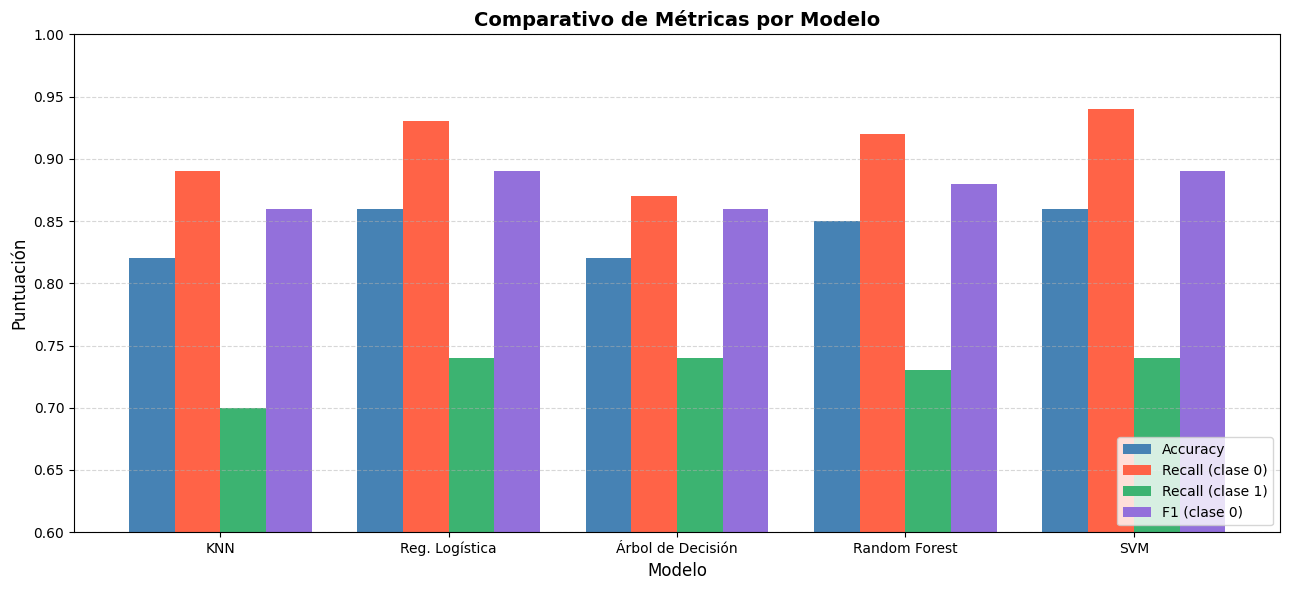

In [1]:
import matplotlib.pyplot as plt
import numpy as np

modelos = ['KNN', 'Reg. Logística', 'Árbol de Decisión', 'Random Forest', 'SVM']
accuracy  = [0.82, 0.86, 0.82, 0.85, 0.86]
recall_0  = [0.89, 0.93, 0.87, 0.92, 0.94]
recall_1  = [0.70, 0.74, 0.74, 0.73, 0.74]
f1_0      = [0.86, 0.89, 0.86, 0.88, 0.89]

x = np.arange(len(modelos))
ancho = 0.2

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - 1.5*ancho, accuracy,  ancho, label='Accuracy',         color='steelblue')
b2 = ax.bar(x - 0.5*ancho, recall_0,  ancho, label='Recall (clase 0)', color='tomato')
b3 = ax.bar(x + 0.5*ancho, recall_1,  ancho, label='Recall (clase 1)', color='mediumseagreen')
b4 = ax.bar(x + 1.5*ancho, f1_0,      ancho, label='F1 (clase 0)',     color='mediumpurple')

ax.set_xlabel('Modelo', fontsize=12)
ax.set_ylabel('Puntuación', fontsize=12)
ax.set_title('Comparativo de Métricas por Modelo', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=10)
ax.set_ylim(0.60, 1.00)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Análisis Comparativo Final

Al observar las métricas de los cinco modelos, se puede concluir lo siguiente:

- **SVM** y **Regresión Logística** comparten la mayor exactitud general (86%) y presentan los mejores F1-scores en ambas clases.
- **SVM** destaca con el recall más alto en la clase 0 (no sobrevivientes: 94%), siendo el modelo más efectivo para detectar a quienes fallecieron.
- **KNN** es el modelo con el rendimiento más limitado, especialmente en el recall de la clase 1 (sobrevivientes: 70%).
- **Árbol de Decisión** y **KNN** comparten la exactitud más baja (82%), aunque el árbol muestra mejor equilibrio entre clases.

*"El modelo que mejor predijo la supervivencia fue la **Regresión Logística** (en conjunto con SVM), ya que presenta el mejor equilibrio entre recall de ambas clases (0.93 y 0.74), combinado con un F1-score sólido en ambas categorías. Esto es crucial porque en un escenario como el del Titanic, identificar correctamente tanto a sobrevivientes como a no sobrevivientes tiene el mismo peso moral y analítico."*

# **5. Recomendaciones Técnicas**

| Modelo | Recomendaciones / Escenarios ideales |
|---|---|
| **KNN** | Siempre escalar antes de usarlo. Mejor opción cuando los datos tienen grupos naturales bien definidos. Si el rendimiento es bajo, reducir `n_neighbors` para capturar mejor los patrones locales. |
| **Regresión Logística** | Primera opción cuando se necesita explicar los resultados a alguien no técnico. Si el modelo no converge, aumentar `max_iter`. Buena línea base para comparar otros modelos. |
| **Árbol de Decisión** | Controlar `max_depth` es clave para no memorizar el dataset. Útil cuando se quiere entender exactamente qué reglas sigue el modelo para tomar decisiones. |
| **Random Forest** | Preferible sobre el árbol individual casi siempre. Si el entrenamiento es lento, reducir `n_estimators`. Tolera bien variables irrelevantes sin necesidad de eliminarlas manualmente. |
| **SVM** | Escalar es indispensable, sin eso el modelo falla. Probar primero con kernel `rbf` y ajustar `C`: valores altos memorizan más, valores bajos generalizan mejor. |

### ¿Por qué escalar en KNN y SVM y no en árboles?

**KNN y SVM** trabajan con distancias y márgenes entre puntos. Si `Fare` va de 0 a 500 y `Age` de 0 a 80, el modelo le dará automáticamente más importancia a la tarifa solo por tener números más grandes, no porque sea más relevante. Escalar elimina ese sesgo.

**Los árboles** no miden distancias, sino que preguntan "¿este valor es mayor o menor que X?". Da igual si los datos están escalados o no, la respuesta será la misma.

# **6. Reflexión Final**

## ¿Qué modelo funcionó mejor y por qué?

La **Regresión Logística** y el **SVM** resultaron ser los modelos más efectivos, ambos con un 86% de exactitud general. SVM es el campeón en detectar no sobrevivientes (recall 0.94), mientras que Regresión Logística ofrece el mejor equilibrio interpretación-desempeño. La razón de su éxito está en la naturaleza del dataset: las variables del Titanic tienen relaciones relativamente directas y lineales con la supervivencia, lo cual favorece a estos dos algoritmos.

## ¿Qué variables influyen más en la supervivencia?

Basándonos en el análisis exploratorio y en el comportamiento de los modelos, las variables de mayor peso son:

1. **Sex (Sexo):** La variable más poderosa. Las mujeres sobrevivieron a una tasa significativamente mayor que los hombres debido al protocolo de evacuación "mujeres y niños primero".
2. **Pclass (Clase del pasajero):** Los pasajeros de primera clase tenían acceso prioritario a los botes salvavidas y se ubicaban en cubiertas superiores, lo que facilitó su evacuación.
3. **Age (Edad):** Los niños pequeños tenían mayor prioridad de evacuación. Los adultos mayores, en cambio, tenían menor tasa de supervivencia.
4. **Fare (Tarifa):** Correlacionada con la clase, actúa como un indicador socioeconómico adicional.

## ¿Qué patrones sociales se observan?

El análisis revela con claridad los sistemas de jerarquía social de la época:

- **Género:** Las mujeres sobrevivieron a una tasa de ~74%, mientras que los hombres solo al ~19%. El protocolo "mujeres y niños primero" se aplicó de forma real y medible.
- **Clase social:** El 63% de los pasajeros de primera clase sobrevivió, frente al 47% de segunda clase y apenas el 24% de tercera clase. Los pasajeros más adinerados no solo tenían camarotes en cubiertas superiores (más cerca de los botes), sino también más información y tiempo de reacción.
- **Interseccionalidad:** Una mujer de primera clase tenía una probabilidad de supervivencia cercana al 97%, mientras que un hombre de tercera clase tenía menos del 15%. La combinación de género y clase es el predictor más determinante.

## ¿Qué decisiones se podrían tomar con este análisis?

Aunque el contexto del Titanic es histórico, este tipo de análisis tiene aplicaciones prácticas en:

- **Gestión de emergencias:** Diseñar protocolos de evacuación más equitativos considerando que los patrones sociales (clase, ubicación) afectan la capacidad de respuesta.
- **Políticas de seguridad marítima:** Los resultados evidencian que la ubicación física en el barco (relacionada con la clase del boleto) fue determinante. Esto respalda regulaciones que exijan acceso equitativo a medidas de seguridad independientemente del tipo de boleto.
- **Modelos predictivos de riesgo:** La metodología aplicada puede trasladarse a otros dominios: predecir riesgo de abandono de clientes, riesgo crediticio, o probabilidad de readmisión hospitalaria, usando las mismas técnicas de clasificación supervisada.